# Real World Classification

## Load data

Import the necessary libraries

In [10]:
# If you do not use colab. You should install these packages.
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install graphviz



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [12]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()
# Report the median and standard deviation for columns with missing values
# 1. 找出有缺失值的欄位
missing_info = df.isnull().sum()
cols_with_missing = missing_info[missing_info > 0].index.tolist()

print(f"包含缺失值的欄位: {cols_with_missing}\n")

# 2. 計算並報告這些欄位的中位數與標準差
# 使用 numeric_only=True 確保只處理數值欄位
for col in cols_with_missing:
    median_val = df[col].median()
    std_val = df[col].std()
    
    print(f"--- Column: {col} ---")
    print(f"Median: {median_val:.4f}")
    print(f"Standard Deviation: {std_val:.4f}")
    print()

包含缺失值的欄位: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']

--- Column: SepalLengthCm ---
Median: 6.3000
Standard Deviation: 1.0371

--- Column: SepalWidthCm ---
Median: 2.9000
Standard Deviation: 0.3896

--- Column: PetalLengthCm ---
Median: 5.0856
Standard Deviation: 1.5828

--- Column: PetalWidthCm ---
Median: 1.6000
Standard Deviation: 0.7067

--- Column: BranchLength ---
Median: 16.3000
Standard Deviation: 1.0352



## Data Preprocessing

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5,weights='distance')
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [14]:
df.describe()
# Report the median and standard deviation for columns with missing values

# 2. 計算並報告這些欄位的中位數與標準差
# 使用 numeric_only=True 確保只處理數值欄位
for col in cols_with_missing:
    median_val = df[col].median()
    std_val = df[col].std()
    
    print(f"--- Column: {col} ---")
    print(f"Median: {median_val:.4f}")
    print(f"Standard Deviation: {std_val:.4f}")
    print()

--- Column: SepalLengthCm ---
Median: 6.3000
Standard Deviation: 1.0093

--- Column: SepalWidthCm ---
Median: 2.8932
Standard Deviation: 0.3724

--- Column: PetalLengthCm ---
Median: 5.0382
Standard Deviation: 1.5273

--- Column: PetalWidthCm ---
Median: 1.7000
Standard Deviation: 0.6947

--- Column: BranchLength ---
Median: 16.3000
Standard Deviation: 1.0110



## Data Exploration

In [15]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/mike/NYCU/2026_Spring/DM2026-Assignment-1/.venv/bin/python -m pip install --upgrade pip


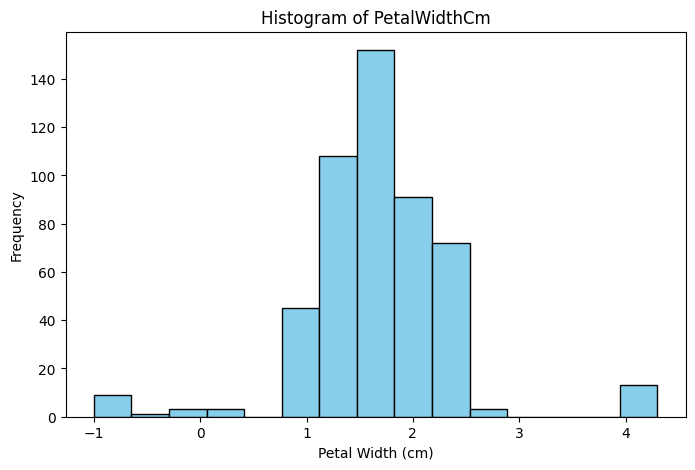

Feature with largest positive correlation: PetalWidthCompactness (0.9917)
Top 5 features with strongest negative correlations:
SepalWidthMajorAxis     -0.096377
SepalGlossIndex         -0.095193
SepalWidthCompactness   -0.088492
SepalWidthCurvature     -0.081369
SepalWidthMinorAxis     -0.074397
dtype: float64


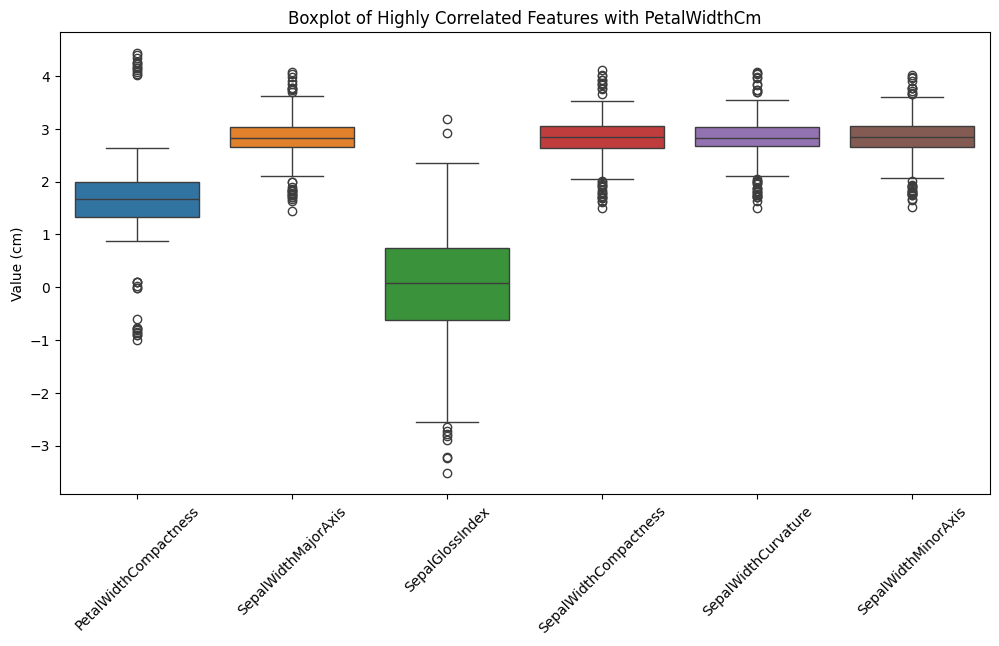

In [16]:
from sklearn.feature_selection import r_regression
import seaborn as sns
# TODO: Complete the 4. Data Exploration
plt.figure(figsize=(8, 5))
plt.hist(df['PetalWidthCm'], bins=15, color='skyblue', edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.show()


# Define target and potential features
target = df['PetalWidthCm']
# Exclude specified columns
features_df = df.drop(columns=['PetalWidthCm', 'Species', 'Id'])

# Calculate Pearson correlation coefficients
# r_regression returns an array of correlations for each feature
correlations = r_regression(features_df, target)
corr_series = pd.Series(correlations, index=features_df.columns)

# Find the largest positive correlation
largest_positive_feature = corr_series.idxmax()
print(f"Feature with largest positive correlation: {largest_positive_feature} ({corr_series.max():.4f})")

# Sort correlations to find the most negative ones
top_5_negative = corr_series.sort_values().head(5)
print("Top 5 features with strongest negative correlations:")
print(top_5_negative)

# Combine the features from 4(b) and 4(c)
selected_features = [largest_positive_feature] + top_5_negative.index.tolist()

# Plotting Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[selected_features])
plt.title('Boxplot of Highly Correlated Features with PetalWidthCm')
plt.ylabel('Value (cm)')
plt.xticks(rotation=45)
plt.show()



## Model Training

### Prepare the data

In [17]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.609250,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680000,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.614423,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320000,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520000,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Section 1: K-fold Cross-Validation


In [18]:
# HW2 Section 1(a): 5-fold cross-validation for L2-regularized logistic regression

from sklearn.model_selection import KFold, cross_val_score
from IPython.display import display

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]
cv = KFold(n_splits=5, shuffle=True, random_state=40)

cv_records = []
for lr in learning_rates:
    for reg_lambda in reg_lambdas:
        model = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=loss_fn,
            act_fn=act_fn,
            grad_fn=grad_fn,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=10000,
            val_ratio=0.2,
            random_state=seed,
            verbose=False,
            plot_curve=False,
        )
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
        cv_records.append({
            'learning_rate': lr,
            'reg_lambda': reg_lambda,
            'mean_accuracy': scores.mean(),
            'std_accuracy': scores.std(),
        })

cv_results = pd.DataFrame(cv_records)
cv_table = cv_results.pivot(index='learning_rate', columns='reg_lambda', values='mean_accuracy')

print('5-fold cross-validation average accuracy on the training data:')
display(cv_table.style.format('{:.4f}'))

top2_settings = cv_results.sort_values(
    ['mean_accuracy', 'std_accuracy'], ascending=[False, True]
).head(2).reset_index(drop=True)

print('Top two hyperparameter settings:')
display(top2_settings.style.format({
    'learning_rate': '{:.3f}',
    'reg_lambda': '{:.1f}',
    'mean_accuracy': '{:.4f}',
    'std_accuracy': '{:.4f}',
}))


5-fold cross-validation average accuracy on the training data:


reg_lambda,1.000000,2.000000,4.000000,8.000000
learning_rate,,,,
0.005000,0.7171,0.7200,0.7257,0.7229
0.010000,0.7229,0.7286,0.7257,0.7171
0.100000,0.7229,0.7257,0.7257,0.7171
0.500000,0.7229,0.6914,0.5343,0.4657


Top two hyperparameter settings:


,learning_rate,reg_lambda,mean_accuracy,std_accuracy
0,0.010,2.0,0.7286,0.0579
1,0.005,4.0,0.7257,0.0331


## Section 1(b): Testing the Top Two Settings


Top 1: lr=0.01, reg_lambda=2.0
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750


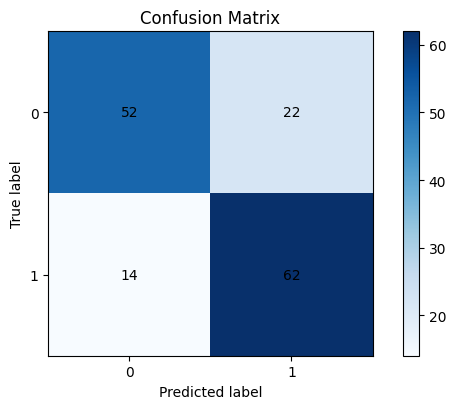

Top 2: lr=0.005, reg_lambda=4.0
Accuracy  : 0.7533
Precision : 0.7241
Recall    : 0.8289
F1-score  : 0.7730


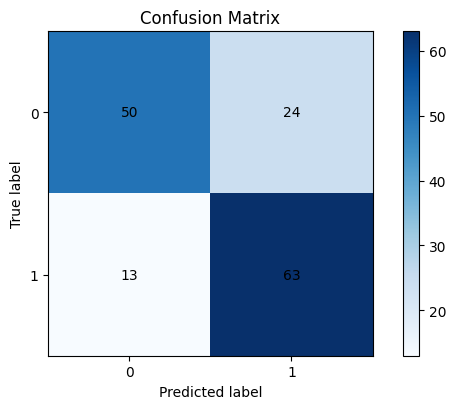

,rank,learning_rate,reg_lambda,Accuracy,Precision,Recall,F1-score
0,1,0.010,2.0,0.7600,0.7381,0.8158,0.7750
1,2,0.005,4.0,0.7533,0.7241,0.8289,0.7730


In [19]:
# HW2 Section 1(b): retrain the top two models on the training data and evaluate on the test data
from model.metrics import evaluate_binary_classifier

section1_test_results = []
section1_models = []

for rank, row in top2_settings.iterrows():
    lr = row['learning_rate']
    reg_lambda = row['reg_lambda']

    final_model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn,
        lr=lr,
        reg_type='l2',
        reg_lambda=reg_lambda,
        n_iteration=10000,
        val_ratio=0.2,
        random_state=seed,
        verbose=False,
        plot_curve=False,
    )
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)

    title = f"Top {rank + 1}: lr={lr}, reg_lambda={reg_lambda}"
    metrics = evaluate_binary_classifier(y_test, y_pred, title=title)
    section1_test_results.append({
        'rank': rank + 1,
        'learning_rate': lr,
        'reg_lambda': reg_lambda,
        **metrics,
    })
    section1_models.append(final_model)

test_results_df = pd.DataFrame(section1_test_results)
display(test_results_df.style.format({
    'learning_rate': '{:.3f}',
    'reg_lambda': '{:.1f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-score': '{:.4f}',
}))


## Section 1(c): Observations


In [20]:
# HW2 Section 1(c): summarize the observations from 1(a) and 1(b)
best_cv = top2_settings.iloc[0]
best_test = test_results_df.sort_values('Accuracy', ascending=False).iloc[0]

print('Observations:')
print(
    f"1. In 5-fold cross-validation, the best average training accuracy was "
    f"{best_cv['mean_accuracy']:.4f}, achieved with learning_rate={best_cv['learning_rate']} "
    f"and reg_lambda={best_cv['reg_lambda']}."
)
print(
    f"2. The top two settings were selected by average CV accuracy and then retrained on the full "
    f"training split before testing, so the test metrics estimate generalization to unseen data."
)
print(
    f"3. On the testing data, the best of the two selected settings by accuracy was "
    f"learning_rate={best_test['learning_rate']} and reg_lambda={best_test['reg_lambda']}, "
    f"with Accuracy={best_test['Accuracy']:.4f}, Precision={best_test['Precision']:.4f}, "
    f"Recall={best_test['Recall']:.4f}, and F1-score={best_test['F1-score']:.4f}."
)
print(
    "4. If several settings have very similar CV accuracy, the simpler preference is to choose "
    "the setting with the smaller CV standard deviation because it is more stable across folds."
)


Observations:
1. In 5-fold cross-validation, the best average training accuracy was 0.7286, achieved with learning_rate=0.01 and reg_lambda=2.0.
2. The top two settings were selected by average CV accuracy and then retrained on the full training split before testing, so the test metrics estimate generalization to unseen data.
3. On the testing data, the best of the two selected settings by accuracy was learning_rate=0.01 and reg_lambda=2.0, with Accuracy=0.7600, Precision=0.7381, Recall=0.8158, and F1-score=0.7750.
4. If several settings have very similar CV accuracy, the simpler preference is to choose the setting with the smaller CV standard deviation because it is more stable across folds.
